In [1]:
import pandas as pd
import numpy as np

years = [2020, 2021, 2022, 2023, 2024, 2025]
dfs = []

for year in years:
    url = f"http://tennis-data.co.uk/{year}/{year}.xlsx"
    print(f"Loading {year}...")
    df_year = pd.read_excel(url)
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal matches: {len(df)}")

Loading 2020...
Loading 2021...
Loading 2022...
Loading 2023...
Loading 2024...
Loading 2025...

Total matches: 14438


In [2]:
# Filter only Completed matches
df = df[df['Comment'] == 'Completed'].copy()
print(f"After filtering only Completed: {df.shape}")

# Step 2: Drop leakage columns (set scores reveal match outcome)
leakage_cols = ['W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
df = df.drop(columns=leakage_cols, errors='ignore')
print(f"After dropping leakage columns: {df.shape}")

After filtering only Completed: (13932, 38)
After dropping leakage columns: (13932, 25)


In [3]:
# Step 3: Drop sparse / useless columns
useless_cols = ['BFEW', 'BFEL', 'ATP']  # BFEW/BFEL: 95% missing. ATP: just an ID
df = df.drop(columns=useless_cols, errors='ignore')
print(f"After dropping sparse/useless columns: {df.shape}")

After dropping sparse/useless columns: (13932, 22)


In [4]:
# Step 4: Handle missing values
# Drop rows with missing critical info (ranks, points, best of)
df = df.dropna(subset=['WRank', 'LRank', 'WPts', 'LPts', 'Best of']).copy()

# Fill betting odds with median (robust to outliers)
odds_cols = ['B365W', 'B365L', 'PSW', 'PSL', 'MaxW', 'MaxL', 'AvgW', 'AvgL']
for col in odds_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"After handling missing values: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

After handling missing values: (13889, 22)
Remaining nulls: 0


In [5]:
# Step 5: Sort chronologically (CRITICAL for time-based features later)
df = df.sort_values('Date').reset_index(drop=True)
print(f"Sorted by date.")
print(f"First match: {df['Date'].min()}")
print(f"Last match: {df['Date'].max()}")
print(f"Final shape: {df.shape}")

Sorted by date.
First match: 2020-01-06 00:00:00
Last match: 2025-11-16 00:00:00
Final shape: (13889, 22)


In [6]:
# Step 6: Final sanity check
print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Total nulls: {df.isnull().sum().sum()}")
df.head()

Final shape: (13889, 22)
Columns: ['Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'B365W', 'B365L', 'PSW', 'PSL', 'MaxW', 'MaxL', 'AvgW', 'AvgL']
Total nulls: 0


,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,...,WPts,LPts,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
0,Doha,Qatar Exxon Mobil Open,2020-01-06,ATP250,Outdoor,Hard,1st Round,3.0,Bublik A.,Mannarino A.,...,919.0,1111.0,2.00,1.72,2.21,1.74,2.25,1.80,2.11,1.72
1,Doha,Qatar Exxon Mobil Open,2020-01-06,ATP250,Outdoor,Hard,1st Round,3.0,Moutet C.,Sandgren T.,...,638.0,803.0,1.57,2.25,1.60,2.47,1.65,2.47,1.59,2.34
2,Doha,Qatar Exxon Mobil Open,2020-01-06,ATP250,Outdoor,Hard,1st Round,3.0,Verdasco F.,Andujar P.,...,1025.0,867.0,1.25,3.75,1.31,3.74,1.33,3.85,1.29,3.53
3,Doha,Qatar Exxon Mobil Open,2020-01-06,ATP250,Outdoor,Hard,1st Round,3.0,Bedene A.,Ymer M.,...,905.0,681.0,1.83,1.83,1.97,1.92,2.00,2.07,1.87,1.92
4,Doha,Qatar Exxon Mobil Open,2020-01-06,ATP250,Outdoor,Hard,1st Round,3.0,Chardy J.,Barrere G.,...,920.0,636.0,1.50,2.50,1.54,2.62,1.57,2.65,1.53,2.47


In [7]:
import numpy as np

# Set random seed for reproducibility (so results are the same every run)
np.random.seed(42)

# Create a random True/False array — True means we keep Winner as Player1, False means we swap
keep_order = np.random.rand(len(df)) > 0.5

# Initialize new Player1 and Player2 columns
df['Player1'] = np.where(keep_order, df['Winner'], df['Loser'])
df['Player2'] = np.where(keep_order, df['Loser'], df['Winner'])

# The target: 1 if Player1 won, 0 if Player2 won
df['target'] = keep_order.astype(int)

# Sanity check: half should be 1, half should be 0
print(f"Target distribution:")
print(df['target'].value_counts())
print()
print(f"Sample rows:")
print(df[['Winner', 'Loser', 'Player1', 'Player2', 'target']].head(10))

Target distribution:
target
0    7037
1    6852
Name: count, dtype: int64

Sample rows:
          Winner          Loser       Player1        Player2  target
0      Bublik A.   Mannarino A.  Mannarino A.      Bublik A.       0
1      Moutet C.    Sandgren T.     Moutet C.    Sandgren T.       1
2    Verdasco F.     Andujar P.   Verdasco F.     Andujar P.       1
3      Bedene A.        Ymer M.     Bedene A.        Ymer M.       1
4      Chardy J.     Barrere G.    Barrere G.      Chardy J.       0
5  Kecmanovic M.    Thompson J.   Thompson J.  Kecmanovic M.       0
6  Krajinovic F.      Edmund K.     Edmund K.  Krajinovic F.       0
7    Wawrinka S.      Chardy J.   Wawrinka S.      Chardy J.       1
8      Bedene A.      Bublik A.     Bedene A.      Bublik A.       1
9   Herbert P.H.  Cecchinato M.  Herbert P.H.  Cecchinato M.       1


In [8]:
# Build P1/P2 versions of all winner/loser features
df['P1_Rank'] = np.where(keep_order, df['WRank'], df['LRank'])
df['P2_Rank'] = np.where(keep_order, df['LRank'], df['WRank'])

df['P1_Pts'] = np.where(keep_order, df['WPts'], df['LPts'])
df['P2_Pts'] = np.where(keep_order, df['LPts'], df['WPts'])

# Betting odds — Bet365
df['P1_B365'] = np.where(keep_order, df['B365W'], df['B365L'])
df['P2_B365'] = np.where(keep_order, df['B365L'], df['B365W'])

# Betting odds — Pinnacle
df['P1_PS'] = np.where(keep_order, df['PSW'], df['PSL'])
df['P2_PS'] = np.where(keep_order, df['PSL'], df['PSW'])

# Betting odds — Max
df['P1_Max'] = np.where(keep_order, df['MaxW'], df['MaxL'])
df['P2_Max'] = np.where(keep_order, df['MaxL'], df['MaxW'])

# Betting odds — Avg (average across bookmakers)
df['P1_Avg'] = np.where(keep_order, df['AvgW'], df['AvgL'])
df['P2_Avg'] = np.where(keep_order, df['AvgL'], df['AvgW'])

# Quick check
print(df[['Player1', 'Player2', 'P1_Rank', 'P2_Rank', 'P1_Pts', 'P2_Pts', 'P1_B365', 'P2_B365', 'target']].head())

        Player1      Player2  P1_Rank  P2_Rank  P1_Pts  P2_Pts  P1_B365  \
0  Mannarino A.    Bublik A.     43.0     55.0  1111.0   919.0     1.72   
1     Moutet C.  Sandgren T.     81.0     68.0   638.0   803.0     1.57   
2   Verdasco F.   Andujar P.     49.0     64.0  1025.0   867.0     1.25   
3     Bedene A.      Ymer M.     58.0     76.0   905.0   681.0     1.83   
4    Barrere G.    Chardy J.     83.0     54.0   636.0   920.0     2.50   

   P2_B365  target  
0     2.00       0  
1     2.25       1  
2     3.75       1  
3     1.83       1  
4     1.50       0  


In [9]:
# Rank difference (negative = P1 is better-ranked)
df['Rank_Diff'] = df['P1_Rank'] - df['P2_Rank']

# Points difference (positive = P1 has more points = better)
df['Pts_Diff'] = df['P1_Pts'] - df['P2_Pts']

# Odds difference for each bookmaker
df['B365_Diff'] = df['P1_B365'] - df['P2_B365']
df['PS_Diff'] = df['P1_PS'] - df['P2_PS']
df['Avg_Diff'] = df['P1_Avg'] - df['P2_Avg']
df['Max_Diff'] = df['P1_Max'] - df['P2_Max']

# Log ratios — sometimes more stable for ranking gaps
df['Rank_Ratio'] = np.log(df['P1_Rank'] / df['P2_Rank'])
df['Pts_Ratio'] = np.log(df['P1_Pts'] / df['P2_Pts'])

print(df[['P1_Rank', 'P2_Rank', 'Rank_Diff', 'Rank_Ratio', 'Pts_Diff', 'B365_Diff', 'target']].head(10))

   P1_Rank  P2_Rank  Rank_Diff  Rank_Ratio  Pts_Diff  B365_Diff  target
0     43.0     55.0      -12.0   -0.246133     192.0      -0.28       0
1     81.0     68.0       13.0    0.174941    -165.0      -0.68       1
2     49.0     64.0      -15.0   -0.267063     158.0      -2.50       1
3     58.0     76.0      -18.0   -0.270290     224.0       0.00       1
4     83.0     54.0       29.0    0.429857    -284.0       1.00       0
5     63.0     62.0        1.0    0.016000      -3.0       0.44       0
6     69.0     40.0       29.0    0.545227    -348.0       0.00       0
7     15.0     54.0      -39.0   -1.280934    1035.0      -2.10       1
8     58.0     55.0        3.0    0.053110     -14.0      -0.44       1
9     65.0     75.0      -10.0   -0.143101     150.0      -0.84       1


In [10]:
# ===== TIME-BASED FEATURES =====
# For each player at each match, compute their win/loss history BEFORE that match

# Track per-player history as we go
from collections import defaultdict

# Storage for each player's match history
player_history = defaultdict(list)  # player_name → list of (date, surface, won_bool)
h2h_history = defaultdict(lambda: defaultdict(list))  # player_a → player_b → list of (date, a_won_bool)

# Lists to store computed features for each row
p1_winrate_all = []
p2_winrate_all = []
p1_winrate_surface = []
p2_winrate_surface = []
p1_recent_form = []
p2_recent_form = []
h2h_p1_wins = []
h2h_p2_wins = []

def winrate(matches_list):
    """Compute win rate from a list of (date, surface, won) tuples."""
    if len(matches_list) == 0:
        return 0.5  # neutral default for new players
    wins = sum(1 for _, _, won in matches_list if won)
    return wins / len(matches_list)

def winrate_on_surface(matches_list, surface):
    """Compute win rate filtered to a specific surface."""
    filtered = [m for m in matches_list if m[1] == surface]
    if len(filtered) == 0:
        return 0.5
    wins = sum(1 for _, _, won in filtered if won)
    return wins / len(filtered)

def recent_form(matches_list, n=10):
    """Win rate over last n matches."""
    recent = matches_list[-n:]
    if len(recent) == 0:
        return 0.5
    wins = sum(1 for _, _, won in recent if won)
    return wins / len(recent)

# Loop through every match in chronological order
for idx, row in df.iterrows():
    p1 = row['Player1']
    p2 = row['Player2']
    surface = row['Surface']
    date = row['Date']
    p1_won = row['target'] == 1

    # ---- Read features from history (BEFORE this match) ----
    p1_winrate_all.append(winrate(player_history[p1]))
    p2_winrate_all.append(winrate(player_history[p2]))

    p1_winrate_surface.append(winrate_on_surface(player_history[p1], surface))
    p2_winrate_surface.append(winrate_on_surface(player_history[p2], surface))

    p1_recent_form.append(recent_form(player_history[p1], n=10))
    p2_recent_form.append(recent_form(player_history[p2], n=10))

    # Head-to-head: P1's wins against P2 historically
    p1_h2h = sum(1 for _, won in h2h_history[p1][p2] if won)
    p2_h2h = sum(1 for _, won in h2h_history[p2][p1] if won)
    h2h_p1_wins.append(p1_h2h)
    h2h_p2_wins.append(p2_h2h)

    # ---- Update history AFTER reading features ----
    player_history[p1].append((date, surface, p1_won))
    player_history[p2].append((date, surface, not p1_won))
    h2h_history[p1][p2].append((date, p1_won))
    h2h_history[p2][p1].append((date, not p1_won))

# Attach all features back to the dataframe
df['P1_Winrate_All'] = p1_winrate_all
df['P2_Winrate_All'] = p2_winrate_all
df['P1_Winrate_Surface'] = p1_winrate_surface
df['P2_Winrate_Surface'] = p2_winrate_surface
df['P1_Form_Last10'] = p1_recent_form
df['P2_Form_Last10'] = p2_recent_form
df['H2H_P1_Wins'] = h2h_p1_wins
df['H2H_P2_Wins'] = h2h_p2_wins

# Derived difference features
df['Winrate_Diff'] = df['P1_Winrate_All'] - df['P2_Winrate_All']
df['Winrate_Surface_Diff'] = df['P1_Winrate_Surface'] - df['P2_Winrate_Surface']
df['Form_Diff'] = df['P1_Form_Last10'] - df['P2_Form_Last10']
df['H2H_Diff'] = df['H2H_P1_Wins'] - df['H2H_P2_Wins']

print("Time-based features added.")
print(df[['Player1', 'Player2', 'P1_Winrate_All', 'P2_Winrate_All',
          'P1_Winrate_Surface', 'P2_Winrate_Surface',
          'P1_Form_Last10', 'P2_Form_Last10',
          'H2H_P1_Wins', 'H2H_P2_Wins', 'target']].tail(10))

Time-based features added.
                  Player1             Player2  P1_Winrate_All  P2_Winrate_All  \
13879          Alcaraz C.            Fritz T.        0.812298        0.663664   
13880          Shelton B.  Auger-Aliassime F.        0.590909        0.621451   
13881           Zverev A.           Sinner J.        0.741573        0.807910   
13882        De Minaur A.            Fritz T.        0.633758        0.661677   
13883          Musetti L.          Alcaraz C.        0.587591        0.812903   
13884          Shelton B.           Sinner J.        0.587571        0.808451   
13885  Auger-Aliassime F.           Zverev A.        0.622642        0.739496   
13886          Alcaraz C.  Auger-Aliassime F.        0.813505        0.623824   
13887        De Minaur A.           Sinner J.        0.634921        0.808989   
13888          Alcaraz C.           Sinner J.        0.814103        0.809524   

       P1_Winrate_Surface  P2_Winrate_Surface  P1_Form_Last10  P2_Form_Last10  \


In [11]:
# ===== ENCODE CATEGORICAL FEATURES =====

# Map categorical columns to integers
surface_map = {'Hard': 0, 'Clay': 1, 'Grass': 2}
court_map = {'Outdoor': 0, 'Indoor': 1}
series_map = {'ATP250': 0, 'ATP500': 1, 'Masters 1000': 2, 'Grand Slam': 3, 'Masters Cup': 4}
round_map = {
    '1st Round': 0, '2nd Round': 1, '3rd Round': 2, '4th Round': 3,
    'Quarterfinals': 4, 'Semifinals': 5, 'The Final': 6, 'Round Robin': 7
}

df['Surface_Enc'] = df['Surface'].map(surface_map)
df['Court_Enc'] = df['Court'].map(court_map)
df['Series_Enc'] = df['Series'].map(series_map)
df['Round_Enc'] = df['Round'].map(round_map)
df['BestOf_Enc'] = df['Best of'].astype(int)  # already numeric, just clean up

# Verify no nulls were introduced
print("Nulls after encoding:")
print(df[['Surface_Enc', 'Court_Enc', 'Series_Enc', 'Round_Enc', 'BestOf_Enc']].isnull().sum())
print()
print("Final dataframe shape:", df.shape)
print("Sample of encoded features:")
print(df[['Surface', 'Surface_Enc', 'Court', 'Court_Enc',
          'Series', 'Series_Enc', 'Round', 'Round_Enc', 'BestOf_Enc']].head())

Nulls after encoding:
Surface_Enc    0
Court_Enc      0
Series_Enc     0
Round_Enc      0
BestOf_Enc     0
dtype: int64

Final dataframe shape: (13889, 62)
Sample of encoded features:
  Surface  Surface_Enc    Court  Court_Enc  Series  Series_Enc      Round  \
0    Hard            0  Outdoor          0  ATP250           0  1st Round   
1    Hard            0  Outdoor          0  ATP250           0  1st Round   
2    Hard            0  Outdoor          0  ATP250           0  1st Round   
3    Hard            0  Outdoor          0  ATP250           0  1st Round   
4    Hard            0  Outdoor          0  ATP250           0  1st Round   

   Round_Enc  BestOf_Enc  
0          0           3  
1          0           3  
2          0           3  
3          0           3  
4          0           3  


In [12]:
# ===== TRAIN/TEST SPLIT =====

# Define which features the model will use
feature_cols = [
    'P1_Rank', 'P2_Rank', 'Rank_Diff', 'Rank_Ratio',
    'P1_Pts', 'P2_Pts', 'Pts_Diff', 'Pts_Ratio',
    'P1_B365', 'P2_B365', 'B365_Diff',
    'P1_PS', 'P2_PS', 'PS_Diff',
    'P1_Avg', 'P2_Avg', 'Avg_Diff',
    'P1_Max', 'P2_Max', 'Max_Diff',
    'P1_Winrate_All', 'P2_Winrate_All', 'Winrate_Diff',
    'P1_Winrate_Surface', 'P2_Winrate_Surface', 'Winrate_Surface_Diff',
    'P1_Form_Last10', 'P2_Form_Last10', 'Form_Diff',
    'H2H_P1_Wins', 'H2H_P2_Wins', 'H2H_Diff',
    'Surface_Enc', 'Court_Enc', 'Series_Enc', 'Round_Enc', 'BestOf_Enc'
]

# Split: train = 2020 to 2024, test = 2025
train_mask = df['Date'] < '2025-01-01'
test_mask = df['Date'] >= '2025-01-01'

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, 'target']
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, 'target']

print(f"Train set: {X_train.shape[0]} matches (2020–2024)")
print(f"Test set:  {X_test.shape[0]} matches (2025)")
print(f"Features:  {X_train.shape[1]}")
print()
print(f"Train target distribution:\n{y_train.value_counts()}")
print()
print(f"Test target distribution:\n{y_test.value_counts()}")

Train set: 11401 matches (2020–2024)
Test set:  2488 matches (2025)
Features:  37

Train target distribution:
target
0    5761
1    5640
Name: count, dtype: int64

Test target distribution:
target
0    1276
1    1212
Name: count, dtype: int64


In [13]:
# ===== MODEL 1: RANDOM FOREST =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# Baseline RF
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_baseline.fit(X_train, y_train)
train_time = time.time() - start

y_pred_rf = rf_baseline.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"RF Baseline Test Accuracy: {acc_rf:.4f} ({acc_rf:.2%})")
print(f"Training time: {train_time:.2f}s")
print(classification_report(y_test, y_pred_rf, target_names=['P2 wins', 'P1 wins']))

# ===== TUNING =====
param_dist_rf = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting RF randomized search...")
start = time.time()
rf_search.fit(X_train, y_train)
search_time = time.time() - start

print(f"Search done in {search_time:.1f}s")
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV accuracy: {rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test)
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print(f"\nTuned RF Test Accuracy: {acc_rf_tuned:.4f} ({acc_rf_tuned:.2%})")
print(f"vs Baseline RF: {acc_rf:.2%}")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['P2 wins', 'P1 wins']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Random Forest Baseline
Training time: 3.79s
Test accuracy: 0.6777 (67.77%)
Baseline to beat: 63.53%

Classification report:
              precision    recall  f1-score   support

     P2 wins       0.68      0.70      0.69      1276
     P1 wins       0.67      0.66      0.67      1212

    accuracy                           0.68      2488
   macro avg       0.68      0.68      0.68      2488
weighted avg       0.68      0.68      0.68      2488

Confusion matrix:
[[888 388]
 [414 798]]


In [15]:
# ===== MODEL 2: XGBOOST =====
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Baseline XGBoost
xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

start = time.time()
xgb_baseline.fit(X_train, y_train)
train_time = time.time() - start

y_pred_xgb = xgb_baseline.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Baseline")
print(f"="*40)
print(f"Training time: {train_time:.2f}s")
print(f"Test accuracy: {acc_xgb:.4f} ({acc_xgb:.2%})")
print(f"vs RF tuned:   {acc_rf_tuned:.2%}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['P2 wins', 'P1 wins']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Baseline
Training time: 2.76s
Test accuracy: 0.6736 (67.36%)
vs RF tuned:   68.45%

              precision    recall  f1-score   support

     P2 wins       0.68      0.69      0.68      1276
     P1 wins       0.67      0.66      0.66      1212

    accuracy                           0.67      2488
   macro avg       0.67      0.67      0.67      2488
weighted avg       0.67      0.67      0.67      2488

Confusion matrix:
[[877 399]
 [413 799]]


In [16]:
# ===== XGBOOST — HYPERPARAMETER TUNING =====
param_dist_xgb = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=25,
    cv=5,                       # changed from 3 to 5
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting XGBoost randomized search...")
start = time.time()
xgb_search.fit(X_train, y_train)
search_time = time.time() - start

print(f"\nSearch done in {search_time:.1f}s")
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV accuracy: {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_
y_pred_xgb_tuned = xgb_best.predict(X_test)
acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)

print(f"\nTuned XGBoost Test Accuracy: {acc_xgb_tuned:.4f} ({acc_xgb_tuned:.2%})")
print(f"vs XGBoost baseline: {acc_xgb:.2%}")
print(f"vs RF tuned:         {acc_rf_tuned:.2%}")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['P2 wins', 'P1 wins']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

Starting XGBoost randomized search (~3-5 min)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Search done in 49.9s
Best params: {'subsample': 1.0, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV accuracy: 0.6816

Tuned XGBoost Test Accuracy: 0.6865 (68.65%)
vs XGBoost baseline: 67.36%
vs RF tuned:         68.45%


In [17]:
# ===== MODEL 3: LIGHTGBM =====
from lightgbm import LGBMClassifier

# Baseline LightGBM
lgbm_baseline = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,        # -1 means no limit (LGBM-specific)
    num_leaves=31,       # main complexity knob in LGBM
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

start = time.time()
lgbm_baseline.fit(X_train, y_train)
train_time = time.time() - start

y_pred_lgbm = lgbm_baseline.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)

print(f"LightGBM Baseline")
print(f"="*40)
print(f"Training time: {train_time:.2f}s")
print(f"Test accuracy: {acc_lgbm:.4f} ({acc_lgbm:.2%})")
print(f"vs XGBoost tuned: {acc_xgb_tuned:.2%}")
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['P2 wins', 'P1 wins']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

LightGBM Baseline
Training time: 1.52s
Test accuracy: 0.6708 (67.08%)
vs XGBoost tuned: 68.65%

              precision    recall  f1-score   support

     P2 wins       0.68      0.69      0.68      1276
     P1 wins       0.66      0.65      0.66      1212

    accuracy                           0.67      2488
   macro avg       0.67      0.67      0.67      2488
weighted avg       0.67      0.67      0.67      2488

Confusion matrix:
[[877 399]
 [420 792]]


In [18]:
# ===== LIGHTGBM — TUNING =====
param_dist_lgbm = {
    'n_estimators': [300, 500, 800],
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_samples': [20, 40]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=25,           # updated from 15
    cv=5,                # updated from 3
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting LightGBM randomized search...")
start = time.time()
lgbm_search.fit(X_train, y_train)
search_time = time.time() - start

print(f"\nSearch done in {search_time:.1f}s")
print(f"Best params: {lgbm_search.best_params_}")
print(f"Best CV accuracy: {lgbm_search.best_score_:.4f}")

lgbm_best = lgbm_search.best_estimator_
y_pred_lgbm_tuned = lgbm_best.predict(X_test)
acc_lgbm_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)

print(f"\nTuned LightGBM Test Accuracy: {acc_lgbm_tuned:.4f} ({acc_lgbm_tuned:.2%})")
print(f"vs LightGBM baseline: {acc_lgbm:.2%}")
print(f"vs XGBoost tuned:     {acc_xgb_tuned:.2%}")
print(f"vs RF tuned:          {acc_rf_tuned:.2%}")
print(classification_report(y_test, y_pred_lgbm_tuned, target_names=['P2 wins', 'P1 wins']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgbm_tuned))

Starting LightGBM randomized search (~1-2 min)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Search done in 65.8s
Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV accuracy: 0.6784

Tuned LightGBM Test Accuracy: 0.6845 (68.45%)
vs LightGBM baseline: 67.08%
vs XGBoost tuned:     68.65%
vs RF tuned:          68.45%


         Model  Test Accuracy  Accuracy %
Naive Baseline       0.635300       63.53
  RF (untuned)       0.677653       67.77
 XGB (untuned)       0.673633       67.36
LGBM (untuned)       0.670820       67.08
    RF (tuned)       0.684486       68.45
   XGB (tuned)       0.686495       68.65
  LGBM (tuned)       0.684486       68.45



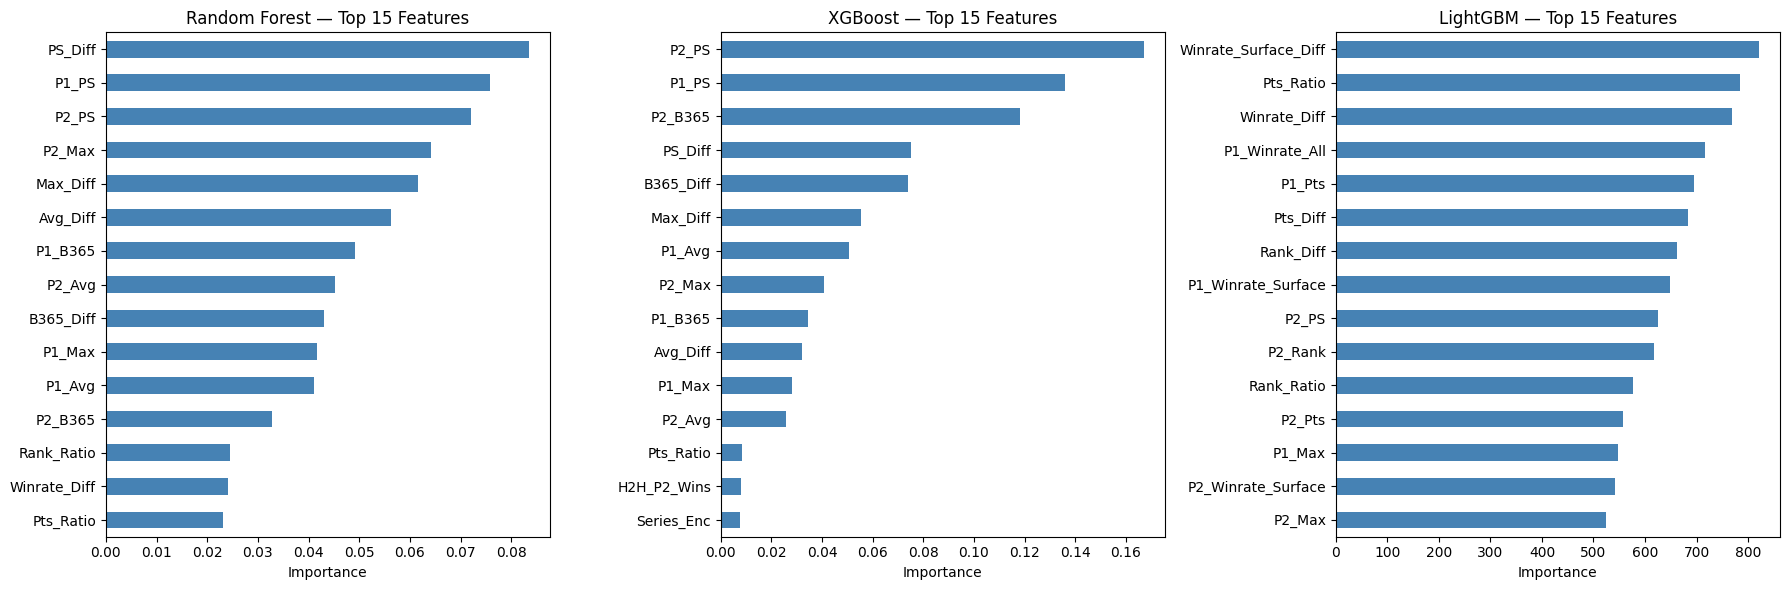

In [19]:
# ===== STEP 9: COMPARISON + FEATURE IMPORTANCE =====
import matplotlib.pyplot as plt
import pandas as pd

# Summary table
summary = pd.DataFrame({
    'Model': ['Naive Baseline', 'RF (untuned)', 'XGB (untuned)', 'LGBM (untuned)',
              'RF (tuned)', 'XGB (tuned)', 'LGBM (tuned)'],
    'Test Accuracy': [0.6353, acc_rf, acc_xgb, acc_lgbm,
                      acc_rf_tuned, acc_xgb_tuned, acc_lgbm_tuned]
})
summary['Accuracy %'] = (summary['Test Accuracy'] * 100).round(2)
print(summary.to_string(index=False))
print()

# Feature importance plots — combined
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model, title in zip(
    axes,
    [rf_best, xgb_best, lgbm_best],
    ['Random Forest', 'XGBoost', 'LightGBM']
):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{title} — Top 15 Features')
    ax.invert_yaxis()
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()